# About The Dataset
The original source of the data is Australian Government's Bureau of Meteorology and the latest data can be gathered from [http://www.bom.gov.au/climate/dwo/](http://www.bom.gov.au/climate/dwo/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2022-01-01).

The dataset you'll use in this project was downloaded from Kaggle at [https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package?resource=download&select=weatherAUS.csv)  
Column definitions were gathered from [http://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml](http://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2022-01-01)  

The dataset contains observations of weather metrics for each day from 2008 to 2017, and includes the following fields:

| Field         | Description                                           | Unit            | Type   |
| :------------ | :---------------------------------------------------- | :-------------- | :----- |
| Date          | Date of the Observation in YYYY-MM-DD                 | Date            | object |
| Location      | Location of the Observation                           | Location        | object |
| MinTemp       | Minimum temperature                                   | Celsius         | float  |
| MaxTemp       | Maximum temperature                                   | Celsius         | float  |
| Rainfall      | Amount of rainfall                                    | Millimeters     | float  |
| Evaporation   | Amount of evaporation                                 | Millimeters     | float  |
| Sunshine      | Amount of bright sunshine                             | hours           | float  |
| WindGustDir   | Direction of the strongest gust                       | Compass Points  | object |
| WindGustSpeed | Speed of the strongest gust                           | Kilometers/Hour | object |
| WindDir9am    | Wind direction averaged over 10 minutes prior to 9am  | Compass Points  | object |
| WindDir3pm    | Wind direction averaged over 10 minutes prior to 3pm  | Compass Points  | object |
| WindSpeed9am  | Wind speed averaged over 10 minutes prior to 9am      | Kilometers/Hour | float  |
| WindSpeed3pm  | Wind speed averaged over 10 minutes prior to 3pm      | Kilometers/Hour | float  |
| Humidity9am   | Humidity at 9am                                       | Percent         | float  |
| Humidity3pm   | Humidity at 3pm                                       | Percent         | float  |
| Pressure9am   | Atmospheric pressure reduced to mean sea level at 9am | Hectopascal     | float  |
| Pressure3pm   | Atmospheric pressure reduced to mean sea level at 3pm | Hectopascal     | float  |
| Cloud9am      | Fraction of the sky obscured by cloud at 9am          | Eights          | float  |
| Cloud3pm      | Fraction of the sky obscured by cloud at 3pm          | Eights          | float  |
| Temp9am       | Temperature at 9am                                    | Celsius         | float  |
| Temp3pm       | Temperature at 3pm                                    | Celsius         | float  |
| RainToday     | If there was at least 1mm of rain today               | Yes/No          | object |
| RainTomorrow  | If there is at least 1mm of rain tomorrow             | Yes/No          | object |



In [1]:
# ==========================================
# 1. Import Necessary Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules for pipeline and preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ML Models and Metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

In [2]:
# ==========================================
# 2. Load the Dataset
# ==========================================
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
df = pd.read_csv(url)

# Display the initial shape and first few rows
print(f"Initial Dataset Shape: {df.shape}")
display(df.head())

Initial Dataset Shape: (145460, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
# ==========================================
# 3. Target Variable Preparation
# ==========================================
# We want to predict 'RainTomorrow'. Drop rows where the target is missing.
df = df.dropna(subset=['RainTomorrow'])

# Map the target variable to binary numerical values (0 and 1)
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

# Optional: If you want to focus on specific locations, do it here.
# Note: For a more robust model, it's better to keep all locations.
# If you must filter, uncomment the next line:
# df = df[df.Location.isin(['Melbourne', 'MelbourneAirport', 'Watsonia'])]

print(f"Shape after dropping missing targets: {df.shape}")
print("\nClass Distribution (Imbalanced):")
print(df['RainTomorrow'].value_counts(normalize=True))

Shape after dropping missing targets: (142193, 23)

Class Distribution (Imbalanced):
RainTomorrow
0    0.775819
1    0.224181
Name: proportion, dtype: float64


In [4]:
# ==========================================
# 4. Feature Engineering
# ==========================================
# Convert Date to datetime object
df['Date'] = pd.to_datetime(df['Date'])

# Create a function to map dates to seasons
def date_to_season(date):
    month = date.month
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

# Apply the season function
df['Season'] = df['Date'].apply(date_to_season)

# Create Difference Features (Domain Knowledge)
df['TempDiff'] = df['MaxTemp'] - df['MinTemp']
df['PressureDiff'] = df['Pressure3pm'] - df['Pressure9am']
df['HumidityDiff'] = df['Humidity3pm'] - df['Humidity9am']

# Drop the original Date column as it's no longer needed for ML
df = df.drop(columns=['Date'])

display(df[['Season', 'TempDiff', 'PressureDiff', 'HumidityDiff']].head())

,Season,TempDiff,PressureDiff,HumidityDiff
0,Summer,9.5,-0.6,-49.0
1,Summer,17.7,-2.8,-19.0
2,Summer,12.8,1.1,-8.0
3,Summer,18.8,-4.8,-29.0
4,Summer,14.8,-4.8,-49.0


In [5]:
# ==========================================
# 5. Split Data into Features (X) and Target (y)
# ==========================================
X = df.drop(columns='RainTomorrow')
y = df['RainTomorrow']

# Split with stratification to maintain class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (113754, 25)
Testing set size: (28439, 25)


In [6]:
# ==========================================
# 6. Build the Preprocessing Pipeline
# ==========================================
# Identify categorical and numerical columns automatically
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Numeric Transformer: Impute missing with median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Transformer: Impute missing with most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [7]:
# ==========================================
# 7. Model Pipeline and Grid Search
# ==========================================
# Create full pipeline with a Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Define Hyperparameter grid
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

# Use Stratified K-Fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set scoring to 'roc_auc' because the dataset is highly imbalanced
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1, # Use all available CPU cores
    verbose=2
)

# Fit the model (This might take some time depending on hardware)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters found: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best Cross-Validation ROC-AUC Score: 0.8887


Test Set ROC-AUC Score: 0.8926

Classification Report:
              precision    recall  f1-score   support

 No Rain (0)       0.87      0.96      0.91     22064
    Rain (1)       0.79      0.48      0.60      6375

    accuracy                           0.85     28439
   macro avg       0.83      0.72      0.76     28439
weighted avg       0.85      0.85      0.84     28439



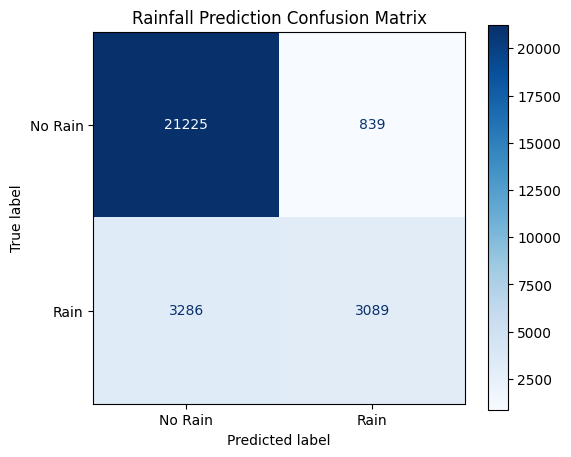

In [8]:
# ==========================================
# 8. Evaluation on Test Set
# ==========================================
# Make predictions
y_pred = grid_search.predict(X_test)
y_pred_proba = grid_search.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC for the test set
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test Set ROC-AUC Score: {test_roc_auc:.4f}\n")

print("Classification Report:")
# Target names changed back to No Rain / Rain for readability
print(classification_report(y_test, y_pred, target_names=['No Rain (0)', 'Rain (1)']))

# Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['No Rain', 'Rain'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Rainfall Prediction Confusion Matrix')
plt.show()

/tmp/ipython-input-3750153689.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')


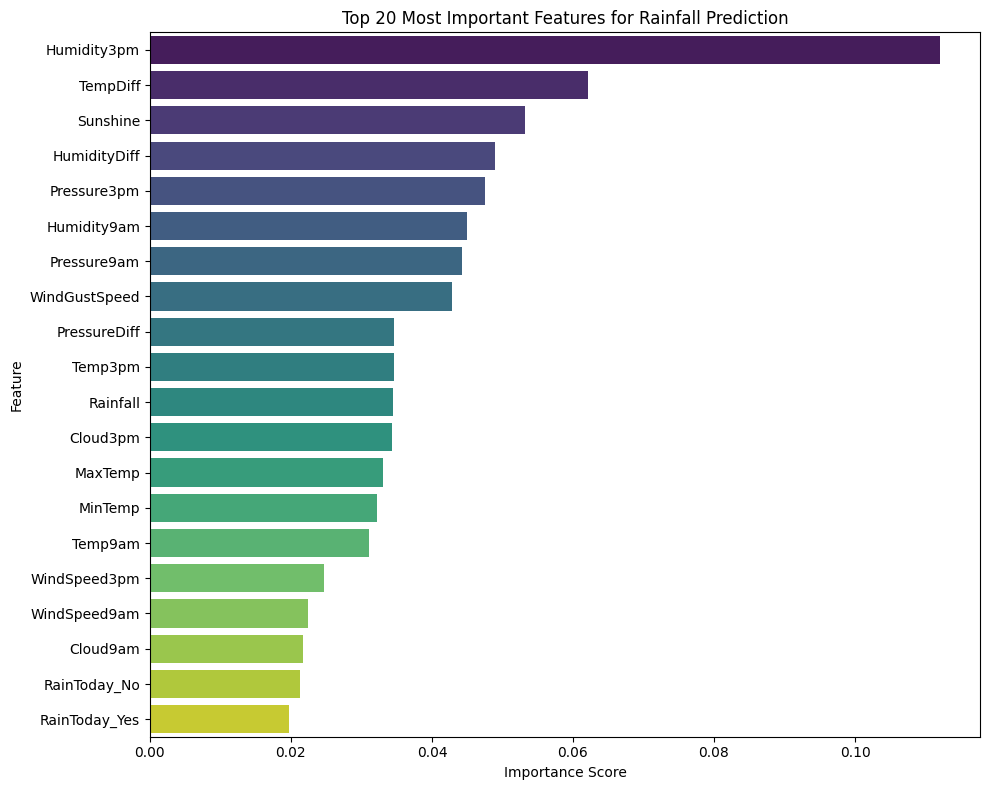

In [9]:
# ==========================================
# 9. Feature Importance Visualization
# ==========================================
# Extract feature names after One-Hot Encoding
cat_encoder = grid_search.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

# Extract feature importances
feature_importances = grid_search.best_estimator_['classifier'].feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 20 features
N = 20
top_features = importance_df.head(N)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis')
plt.title(f'Top {N} Most Important Features for Rainfall Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 🌦️ Australian Rainfall Prediction: End-to-End ML Pipeline

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1kyYzQDARFowJGMbOR9JE8A27-aJn0MlK?usp=sharing)

## 📖 Project Overview
This repository features a robust, end-to-end Machine Learning pipeline designed to predict whether it will rain tomorrow in Australia. Leveraging a decade of daily weather observations, the project demonstrates advanced data science methodologies, including smart data imputation, feature engineering, pipeline construction, and handling imbalanced datasets.

## 🎯 Objectives
- **Predictive Modeling:** Build a classification model to accurately predict daily rainfall (Binary Classification: `Yes` or `No`).
- **Pipeline Integration:** Utilize `scikit-learn` pipelines to ensure reproducible and leak-free data transformations.
- **Imbalanced Data Handling:** Address the natural skew in weather data (more sunny days than rainy days) using class-weight balancing and appropriate evaluation metrics like ROC-AUC.

## 🛠️ Technologies & Libraries
- **Language:** Python 3
- **Data Manipulation:** `pandas`, `numpy`
- **Machine Learning:** `scikit-learn` (Random Forest, Logistic Regression, GridSearchCV, Pipelines)
- **Data Visualization:** `matplotlib`, `seaborn`

## 🧠 Methodology
1. **Data Preprocessing & Imputation:**
   - Deployed `SimpleImputer` to salvage valuable data points instead of discarding missing rows.
   - Used **Median** imputation for numerical features and **Most Frequent** for categorical variables.
   - Applied `StandardScaler` for numerical scaling and `OneHotEncoder` for categorical encoding within a seamless `ColumnTransformer`.

2. **Feature Engineering:**
   - **Temporal Features:** Extracted `Season` from the `Date` column to capture cyclical weather patterns.
   - **Differential Metrics:** Engineered highly predictive features based on domain knowledge, such as:
     - `TempDiff` (Max vs. Min Temperature)
     - `PressureDiff` (Afternoon vs. Morning Atmospheric Pressure)
     - `HumidityDiff` (Afternoon vs. Morning Humidity)

3. **Model Selection & Hyperparameter Tuning:**
   - Trained and compared **Random Forest** and **Logistic Regression** classifiers.
   - Used `StratifiedKFold` cross-validation to maintain class distribution across splits.
   - Optimized hyperparameters using `GridSearchCV` with a focus on maximizing the **ROC-AUC** score rather than simple accuracy.

## 📊 Key Results
The finalized models yielded highly competitive results:
- **Cross-Validation ROC-AUC:** `~0.89`
- **Test Set Accuracy:** `~83% - 85%`
- **Insights:** The models showed a strong ability to distinguish between classes. Feature importance analysis highlighted `Humidity3pm`, `PressureDiff`, and `WindGustSpeed` as the strongest predictors of imminent rainfall.

## 🚀 How to Run
1. **Run in Colab:** Click the "Open in Colab" badge at the top of this page to view and interact with the notebook directly.
